# All Uncertain Channels

## 1. Descriptions
In this experiment, let's assume that we are uncertain about the performance of all four channels Let's study how the Bayesian experimental design (BED) framework can help strengthen our knowledge and reduce our uncertainty.

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import polars as pl
import polars.selectors as cs
from bedmmm.data.generator import DataGenerator
from bedmmm.experiment_designer import ExperimentDesigner
from bedmmm.model import MarketingMixModel
from thesis.plot import (
    plot_experiment_posterior_response_curve,
    plot_experiment_posterior_response_curve_multiple,
    plot_experiment_posterior_vs_ground_truth,
    plot_generated_data_on_response_curve,
    plot_posterior_response_curve,
    plot_posterior_response_curve_multiple,
    plot_posterior_vs_ground_truth,
)

In [2]:
plt.rcParams.update(
    {
        "font.size": 18,
        "axes.labelsize": 20,
        "axes.titlesize": 20,
        "legend.fontsize": 18,
        "xtick.labelsize": 18,
        "ytick.labelsize": 18,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

## 2. Synthetic Data Generation

In [3]:
np.random.seed(10)
generator = (
    DataGenerator(
        n_time_periods=52,  # weeks
        n_future_periods=4,
    )
    .generate_baseline(
        base=10,
        noise=0.0,
    )
    # Seasonality generated using sine wave
    .generate_control(
        control_effect=1,
        noise=1,
    )
    # 1. Low retention rate, high saturation, high shape
    .generate_media(
        retention_rate=0.2,
        saturation=5,
        shape=3,
        metric_lower_bound=2,
        noise=1.0,
    )
    # 2. Low retention rate, low saturation, low shape
    .generate_media(
        retention_rate=0.2,
        saturation=2,
        shape=1,
        metric_lower_bound=2,
        noise=1.0,
    )
    # 3. High retention rate, high saturation, high shape
    .generate_media(
        retention_rate=0.8,
        saturation=6,
        shape=3,
        metric_lower_bound=2,
        noise=1.0,
    )
    # 4. High retention rate, low saturation, low shape
    .generate_media(
        retention_rate=0.8,
        saturation=2,
        shape=1,
        metric_lower_bound=2,
        noise=1.0,
    )
    .generate_target(noise=3)
)

data = generator.collect()
media_param_df, control_param_df = generator.get_parameters()

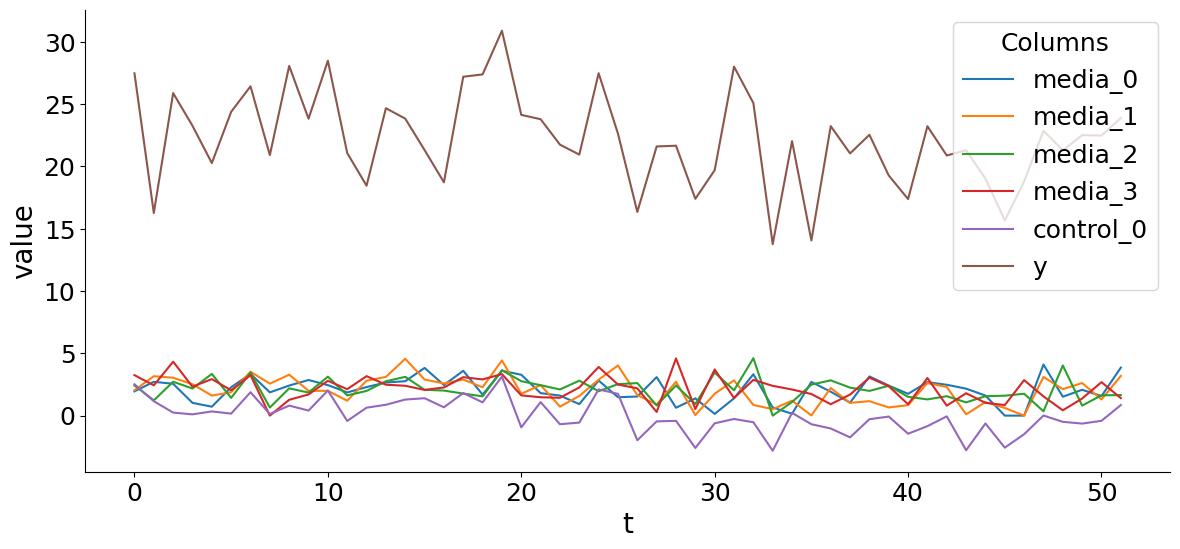

In [4]:
fig, ax = plt.subplots(figsize=(14, 6))

for column in data.columns:
    ax.plot(
        data.with_row_index("time_index")["time_index"],
        data[column],
        label=column,
    )

ax.set_xlabel("t")
ax.set_ylabel("value")
ax.legend(title="Columns")

plt.show()

Let's show where on the response curves the generated media data is:

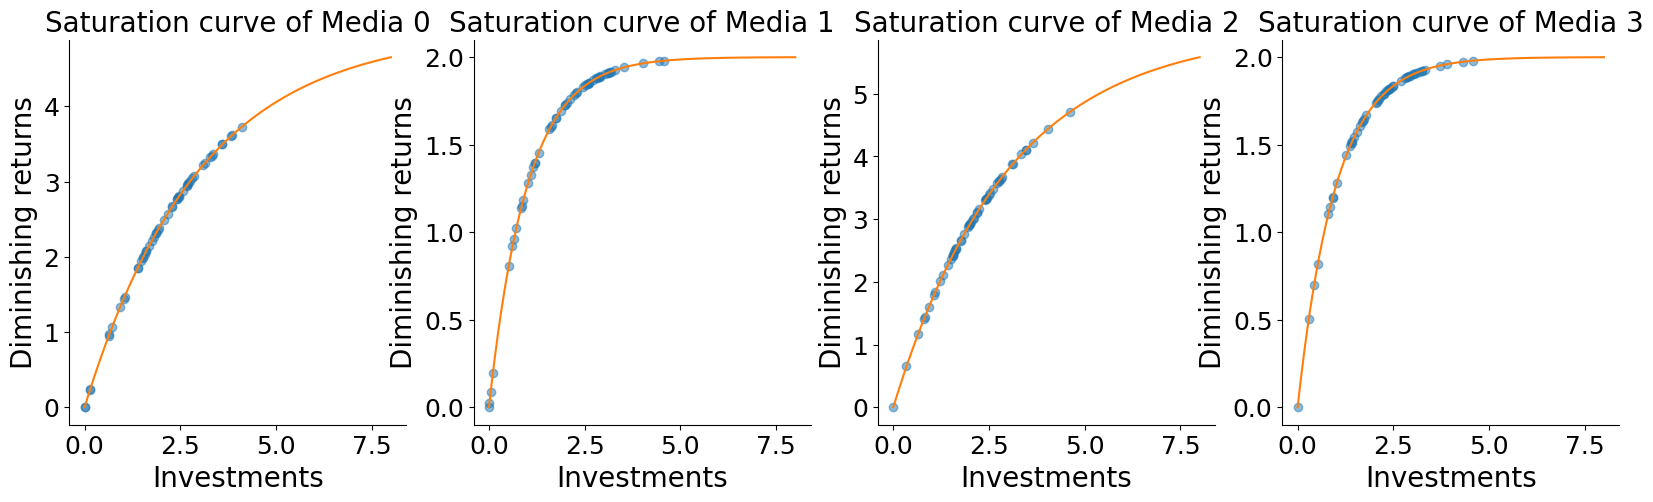

In [5]:
plot_generated_data_on_response_curve(data, media_param_df)

## 3. Fit a Marketing Mix Model (MMM)

Let's fit a MMM where the prior distributions of the Media channel 0 are chosen to reflect the high uncertainty while the prior distributions of all other channels are tight.

In [6]:
model_config = {
    #
    # Media channel 0 priors (high uncertainty)
    "retention_rate_lb_0": 0.1,
    "retention_rate_ub_0": 0.9,
    "shape_mu_0": 2,
    "shape_sigma_0": 2,
    "saturation_mu_0": 4,
    "saturation_sigma_0": 2,
    #
    # Media channel 1 priors (high uncertainty)
    "retention_rate_lb_1": 0.1,
    "retention_rate_ub_1": 0.9,
    "shape_mu_1": 2,
    "shape_sigma_1": 2,
    "saturation_mu_1": 4,
    "saturation_sigma_1": 2,
    #
    # Media channel 2 priors (high uncertainty)
    "retention_rate_lb_2": 0.1,
    "retention_rate_ub_2": 0.9,
    "shape_mu_2": 2,
    "shape_sigma_2": 2,
    "saturation_mu_2": 4,
    "saturation_sigma_2": 2,
    #
    # Media channel 3 priors (high uncertainty)
    "retention_rate_lb_3": 0.1,
    "retention_rate_ub_3": 0.9,
    "shape_mu_3": 2,
    "shape_sigma_3": 2,
    "saturation_mu_3": 4,
    "saturation_sigma_3": 2,
    #
    # Control
    "gamma_mu_0": 1.0,
    "gamma_sigma_0": 1.0,
    #
    # Baseline
    "baseline_mu": 10.0,
    "baseline_sigma": 0.1,
    #
    # Observation noise
    "obs_sigma": 3,
}
sampler_config = {
    "draws": 9_000,
    "tune": 3_000,
    "chains": 4,
    "cores": 4,
    "target_accept": 0.95,
}


model = MarketingMixModel(
    model_config=model_config,
    sampler_config=sampler_config,
)

In [7]:
idata = model.fit(
    data.drop(["y"]).to_pandas(),
    data["y"].to_pandas(),
    random_seed=42,
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [retention_rates, shapes, saturations, gammas, baseline]


Output()

Sampling 4 chains for 3_000 tune and 9_000 draw iterations (12_000 + 36_000 draws total) took 186 seconds.
Sampling: [baseline, gammas, retention_rates, saturations, shapes, y]
Sampling: [y]


Output()

In [8]:
summary_df = az.summary(idata)
# az.plot_trace(idata, figsize=(15, 20));

### 3.1 Comparison between Posterior Distributions and Ground Truth

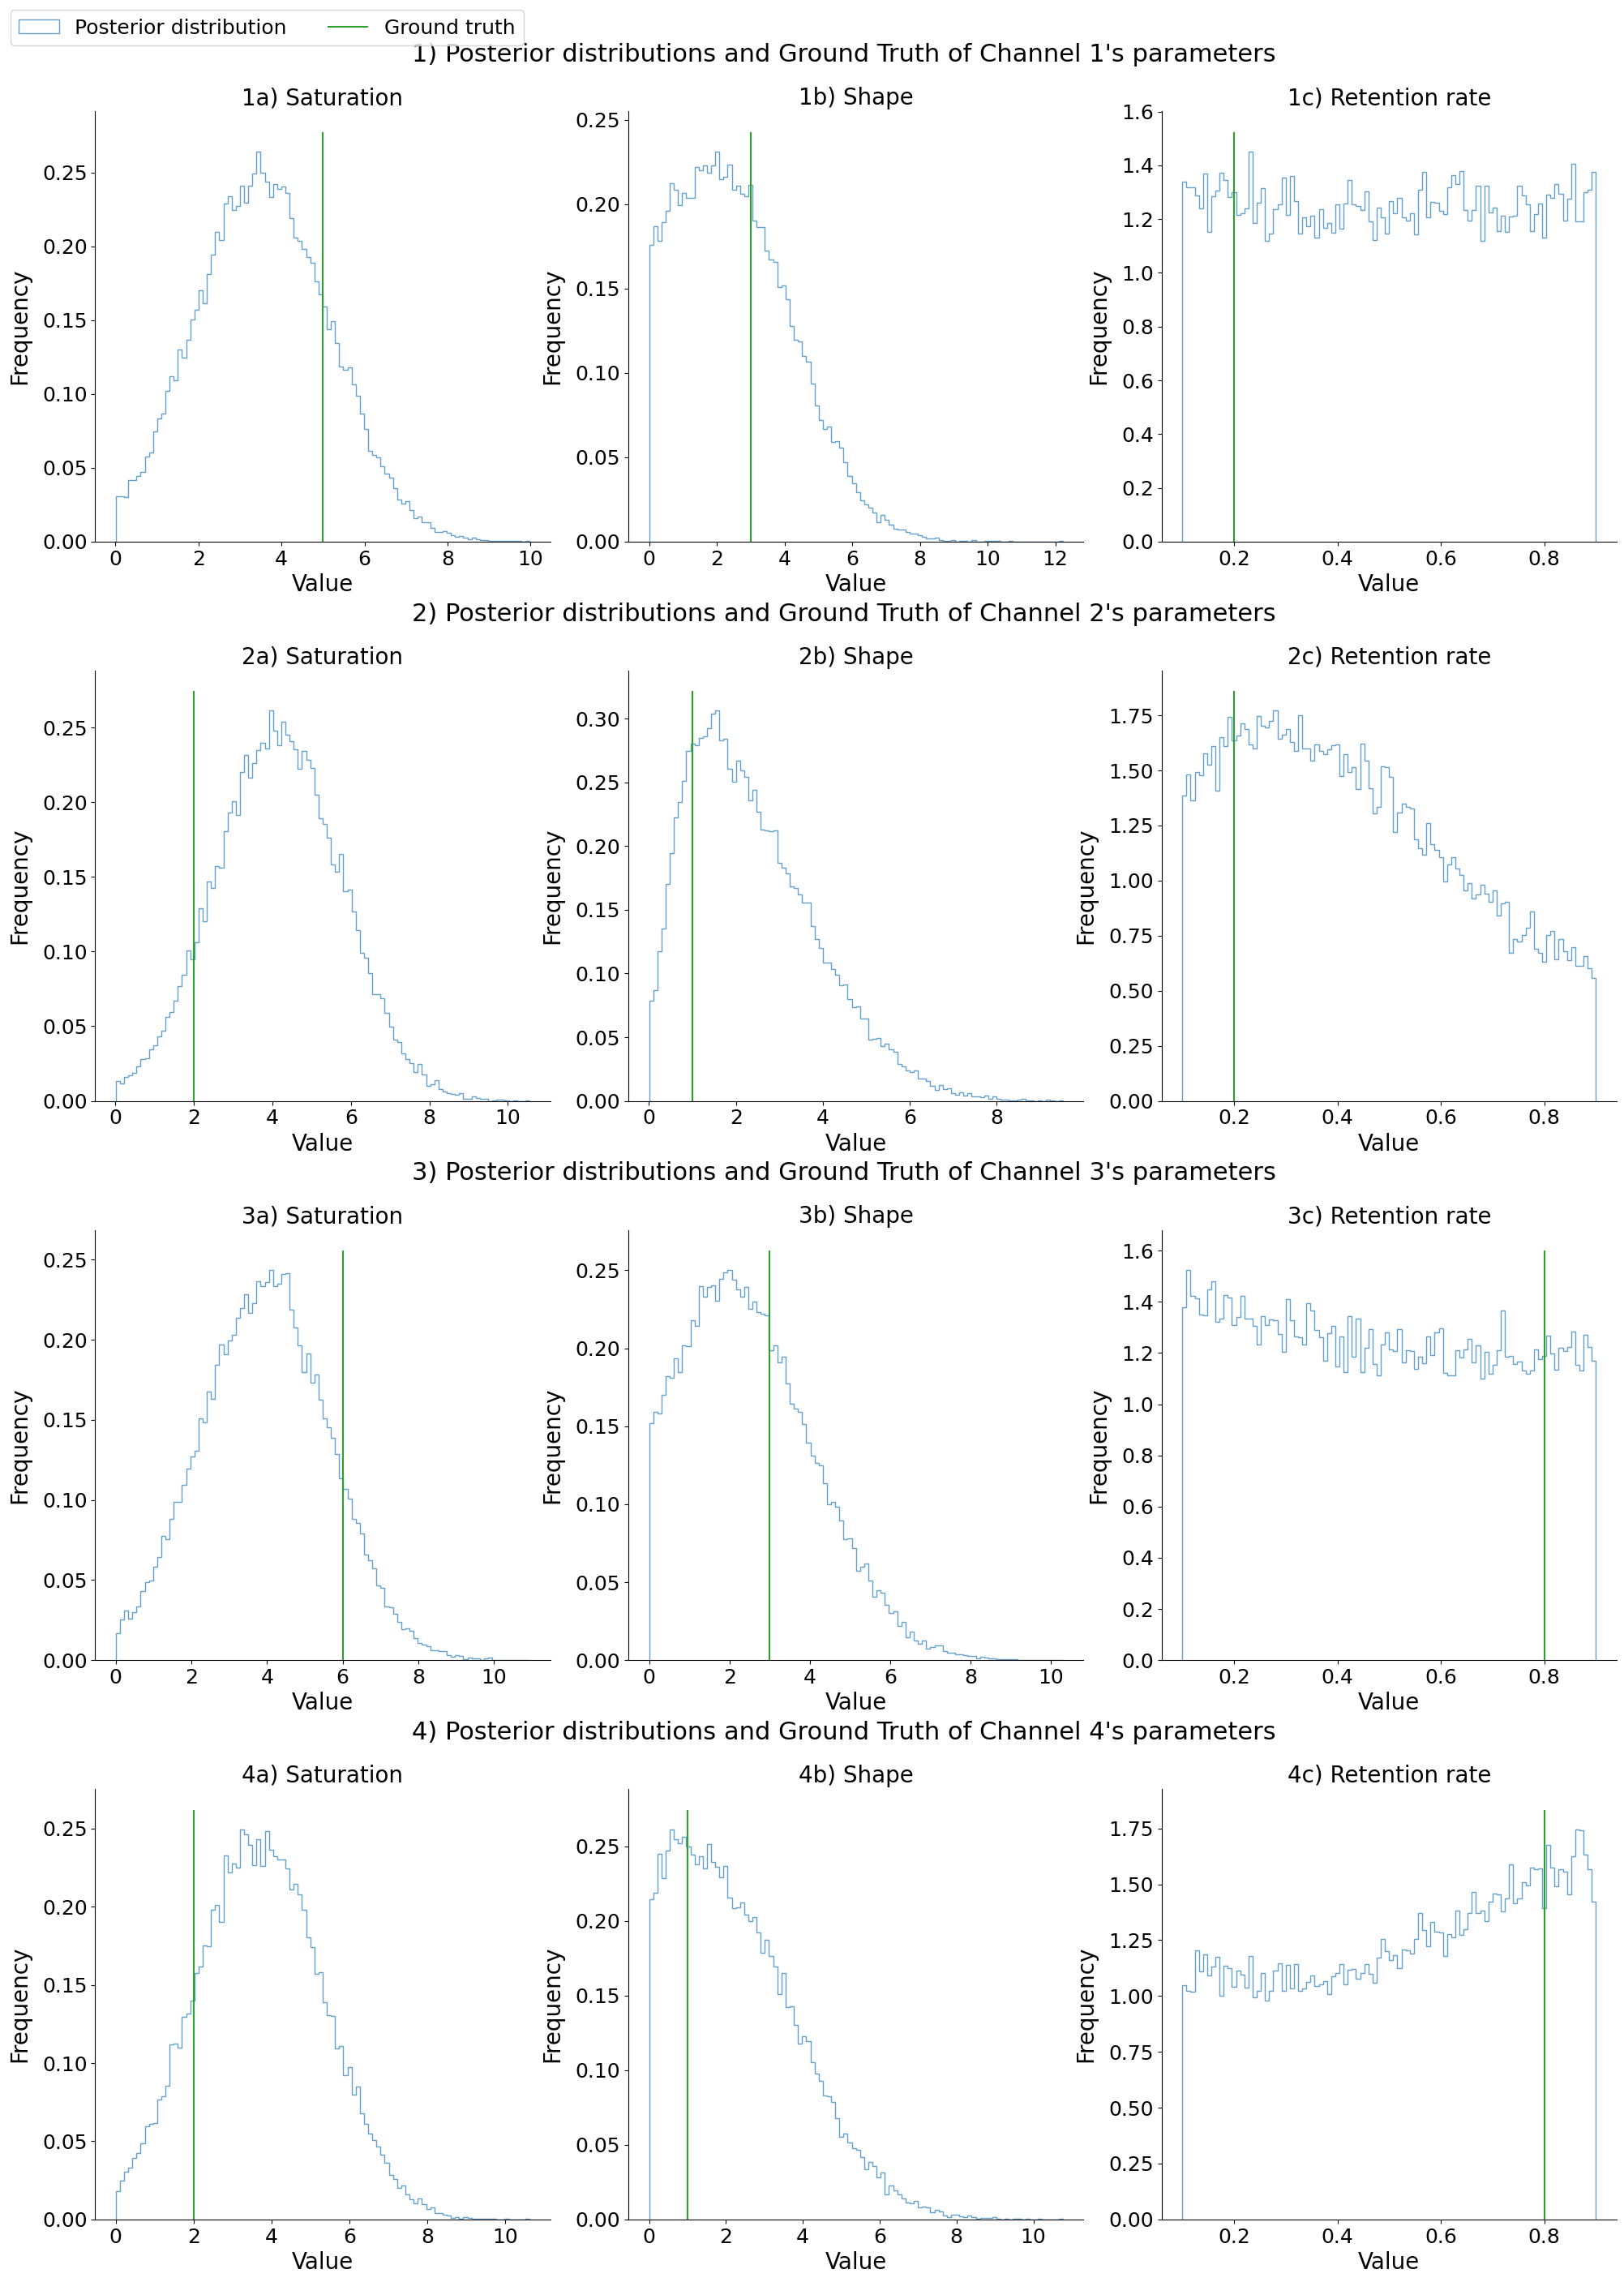

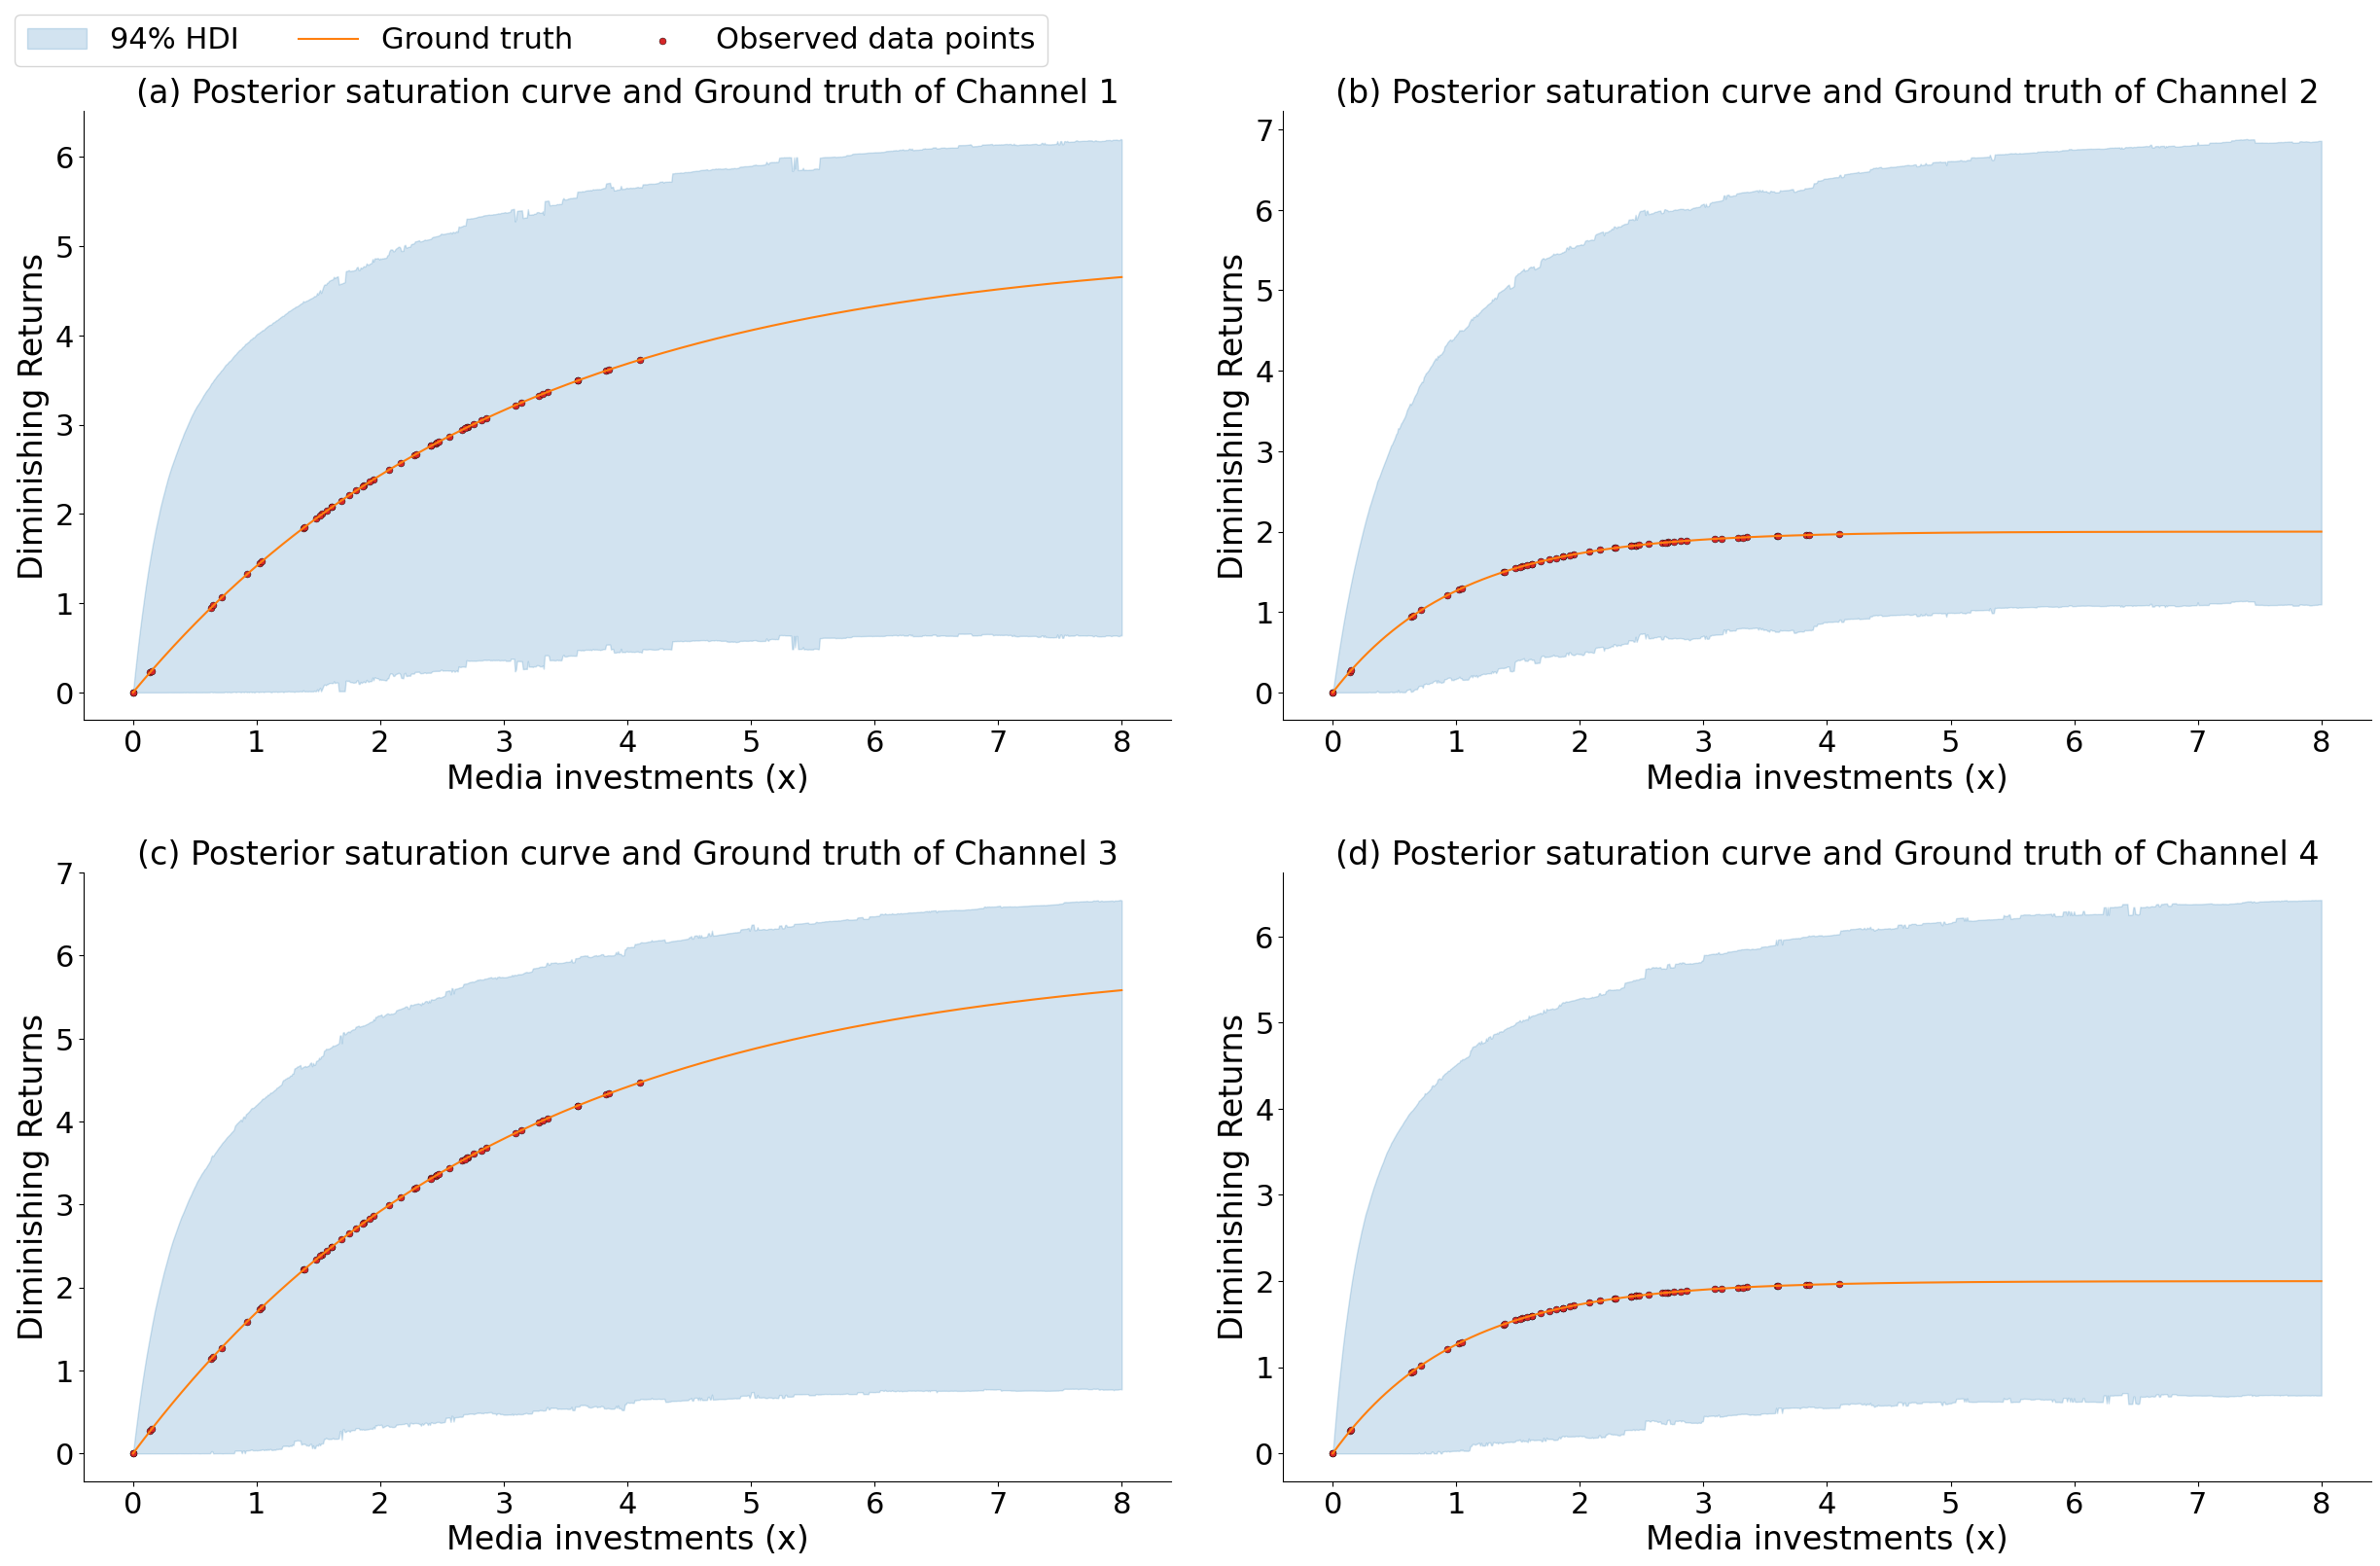

In [9]:
plot_posterior_vs_ground_truth(
    idata,
    media_param_df,
    ["media_0", "media_1", "media_2", "media_3"],
    figsize=(20, 28),
    subplot_adjust_kwargs={"top": 0.95, "hspace": 0.3},
)

plot_posterior_response_curve_multiple(
    idata,
    data=data,
    media_param_df=media_param_df,
    media_feature_names=["media_0", "media_1", "media_2", "media_3"],
)

## 4. Bayesian Experiment Design (BED)

When generating the synthetic data, a dataset, which we call "future data", is also generated along with the data used to fit the model above. "Future data" is not used to fit the model but considered as the budget planning for marketing investments. This helps us quantify the difference between the investments recommended in the optimal experiment and the planned budget (which the marketers are already comfortable of investing).

In [10]:
future_data = generator.collect(data_type="future")
future_control_vars = (
    future_data.slice(0, 1)
    .select(cs.starts_with("control_"))
    .to_numpy()
    .flatten()
)
future_media_data = (
    future_data.slice(0, 1)
    .select(cs.starts_with("media_"))
    .to_numpy()
    .flatten()
)

In [11]:
future_media_data

array([1.41826055, 3.03774116, 2.5643959 , 3.32363377])

### 4.1 Optimize for response curve parameters

In [12]:
d_hat_curve_param = (
    ExperimentDesigner(n_media_channels=4, c=future_control_vars)
    .add_posterior_samples(idata)
    .configure_experiment_space(
        lower_bound=np.zeros(4),
        upper_bound=np.ones(4) * 100,
    )
    # .configure_regularization(
    #     x_0=future_media_data,
    #     regularized_type="cost",
    #     regularized_weight=0.1,
    # )
    .configure_target_variables(
        [
            "saturation",
            "shape",
            # "retention_rate",
        ]
    )
    .find_optimal_experiment()
)
print(f"Optimal experiment found for curve parameters: {d_hat_curve_param}")

generator_with_dhat_curve_param = (
    generator
    #
    .generate_new_observation(x=d_hat_curve_param, c=future_control_vars)
)
data_with_dhat_curve_param = generator_with_dhat_curve_param.collect()

model_with_dhat_curve_param = MarketingMixModel(
    model_config=model_config,
    sampler_config=sampler_config,
)

idata_with_dhat_curve_param = model_with_dhat_curve_param.fit(
    data_with_dhat_curve_param.drop(["y"]).to_pandas(),
    data_with_dhat_curve_param["y"].to_pandas(),
    random_seed=42,
)

summary_with_dhat_curve_param_df = az.summary(idata_with_dhat_curve_param)

  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: -0.051176360044386346
        x: [ 4.822e+01  3.488e+01  0.000e+00  0.000e+00]
      nit: 7
      jac: [-7.772e-07 -9.231e-06  7.345e-03  6.182e-03]
     nfev: 95
     njev: 19
 hess_inv: <4x4 LbfgsInvHessProduct with dtype=float64>
Optimal experiment found for curve parameters: [48.22096916 34.87763907  0.          0.        ]


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [retention_rates, shapes, saturations, gammas, baseline]


Output()

Sampling 4 chains for 3_000 tune and 9_000 draw iterations (12_000 + 36_000 draws total) took 221 seconds.
Sampling: [baseline, gammas, retention_rates, saturations, shapes, y]
Sampling: [y]


Output()

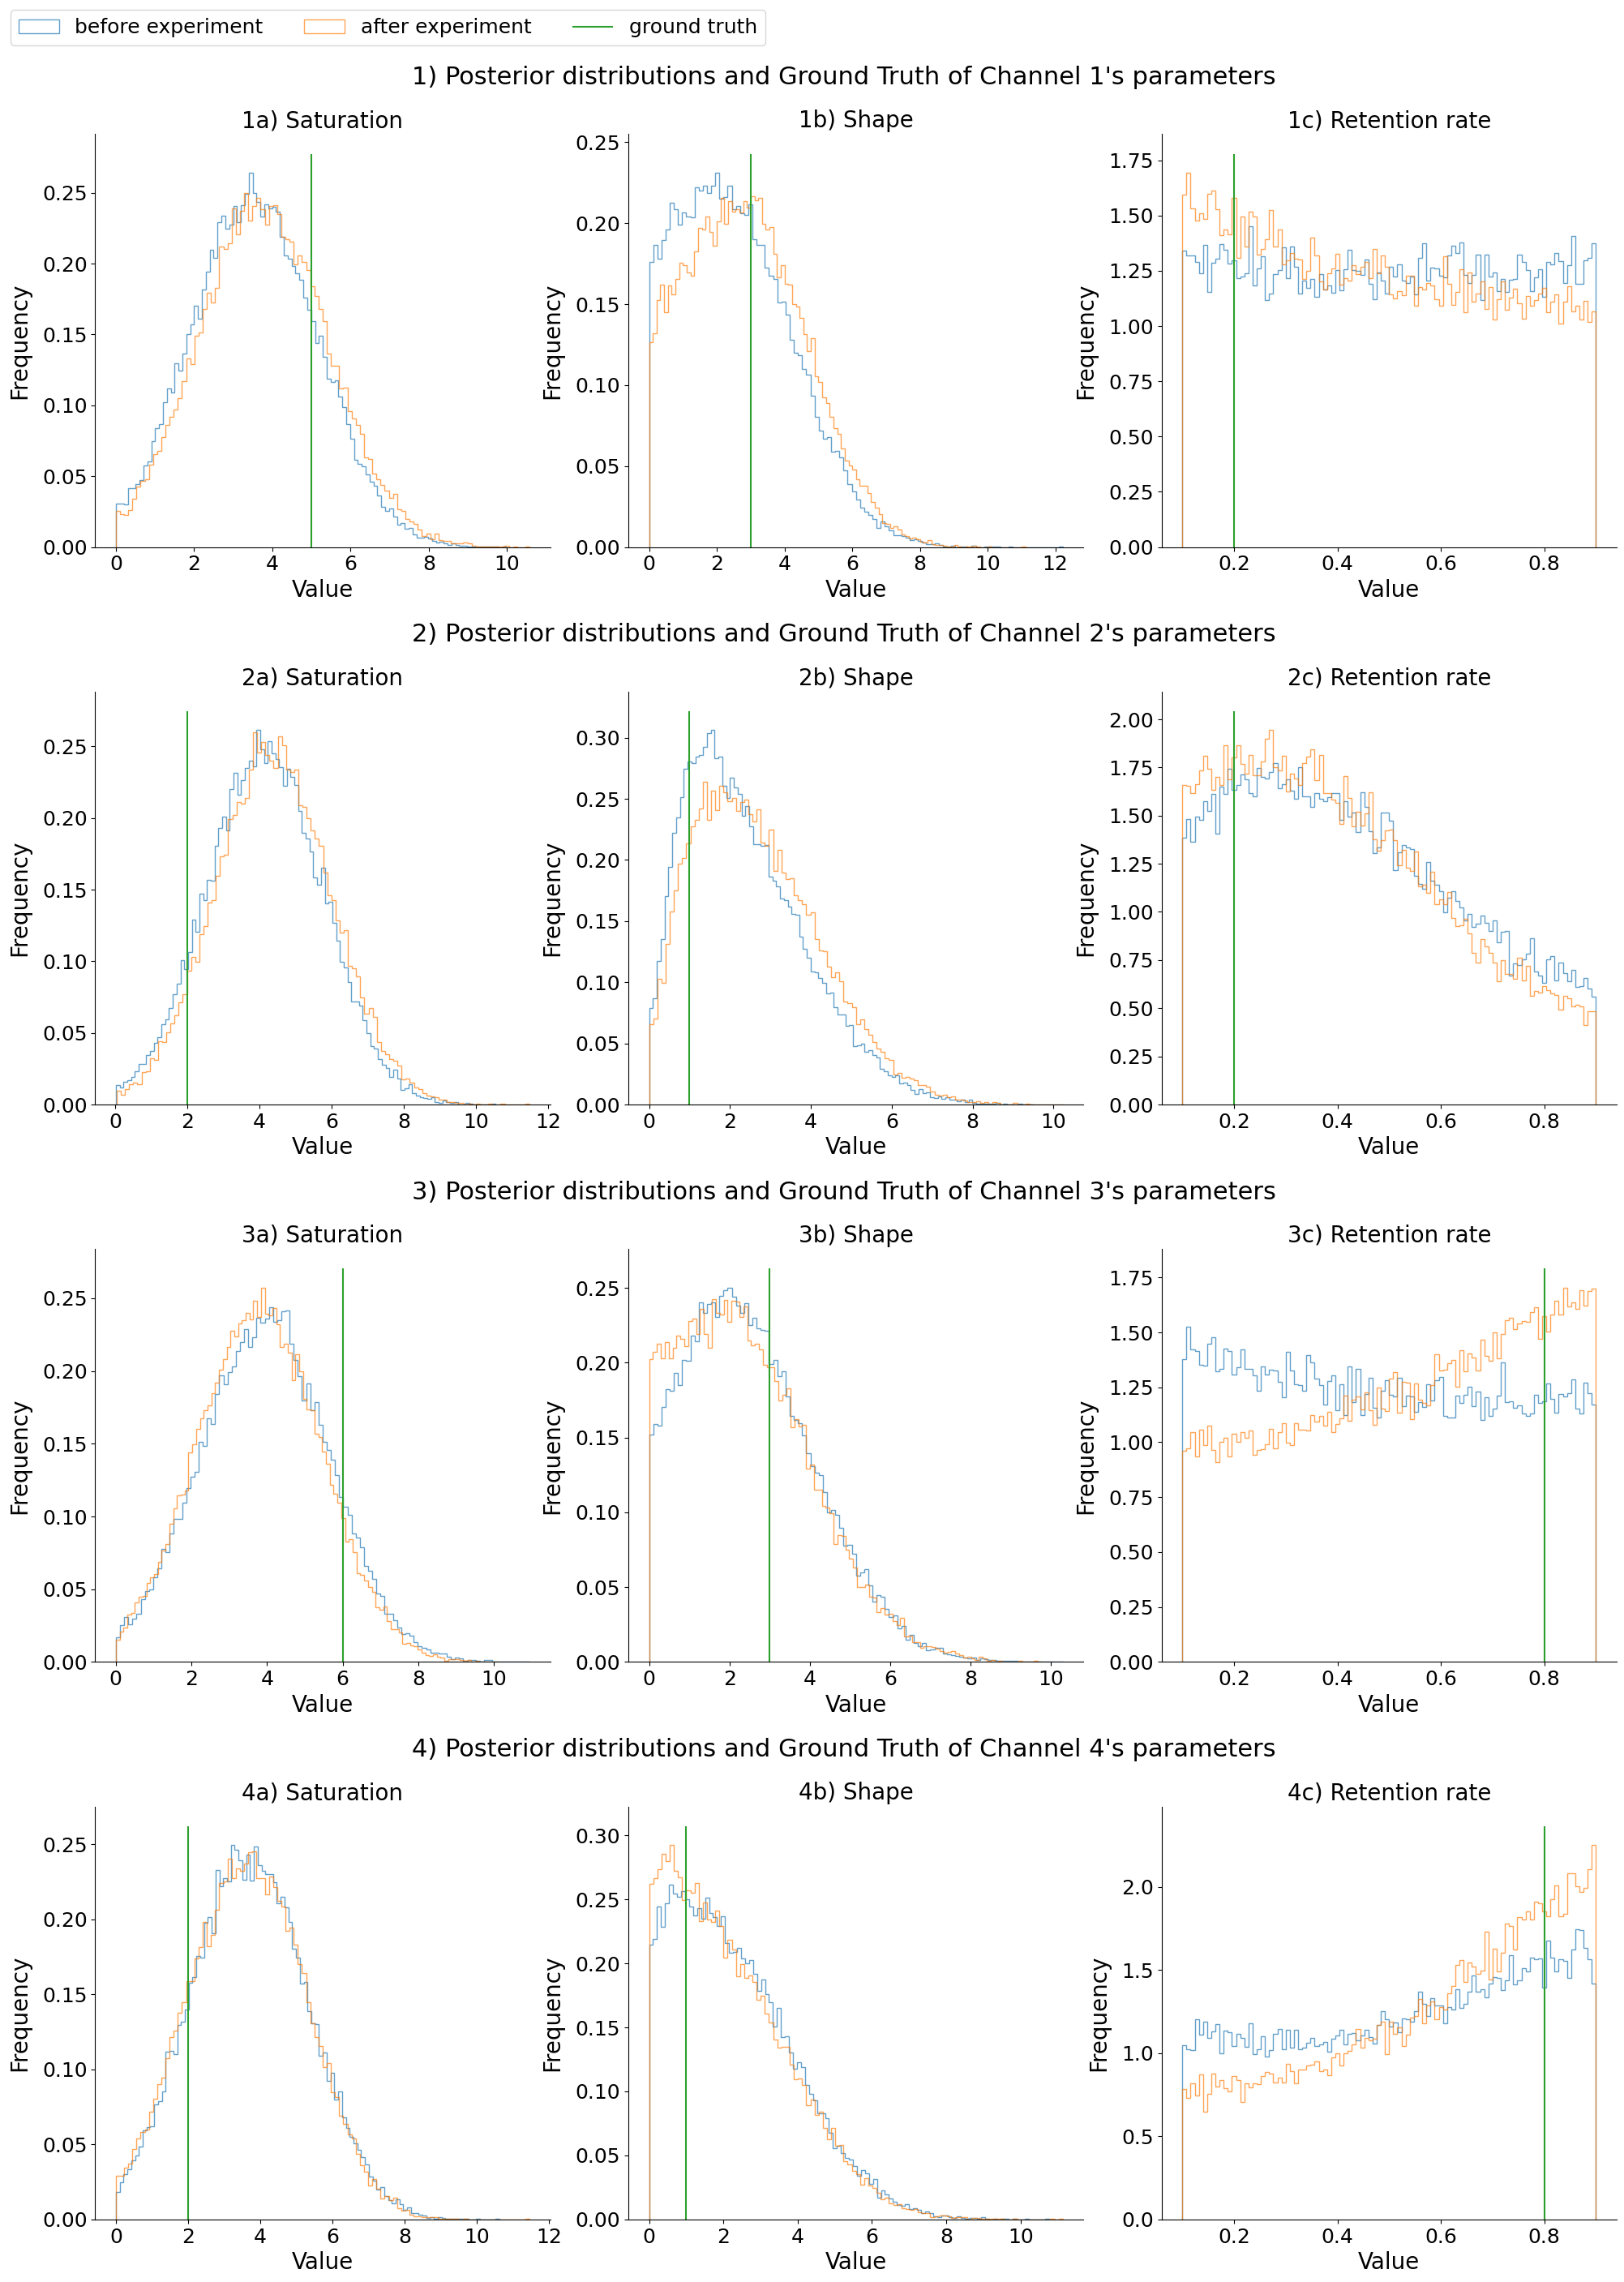

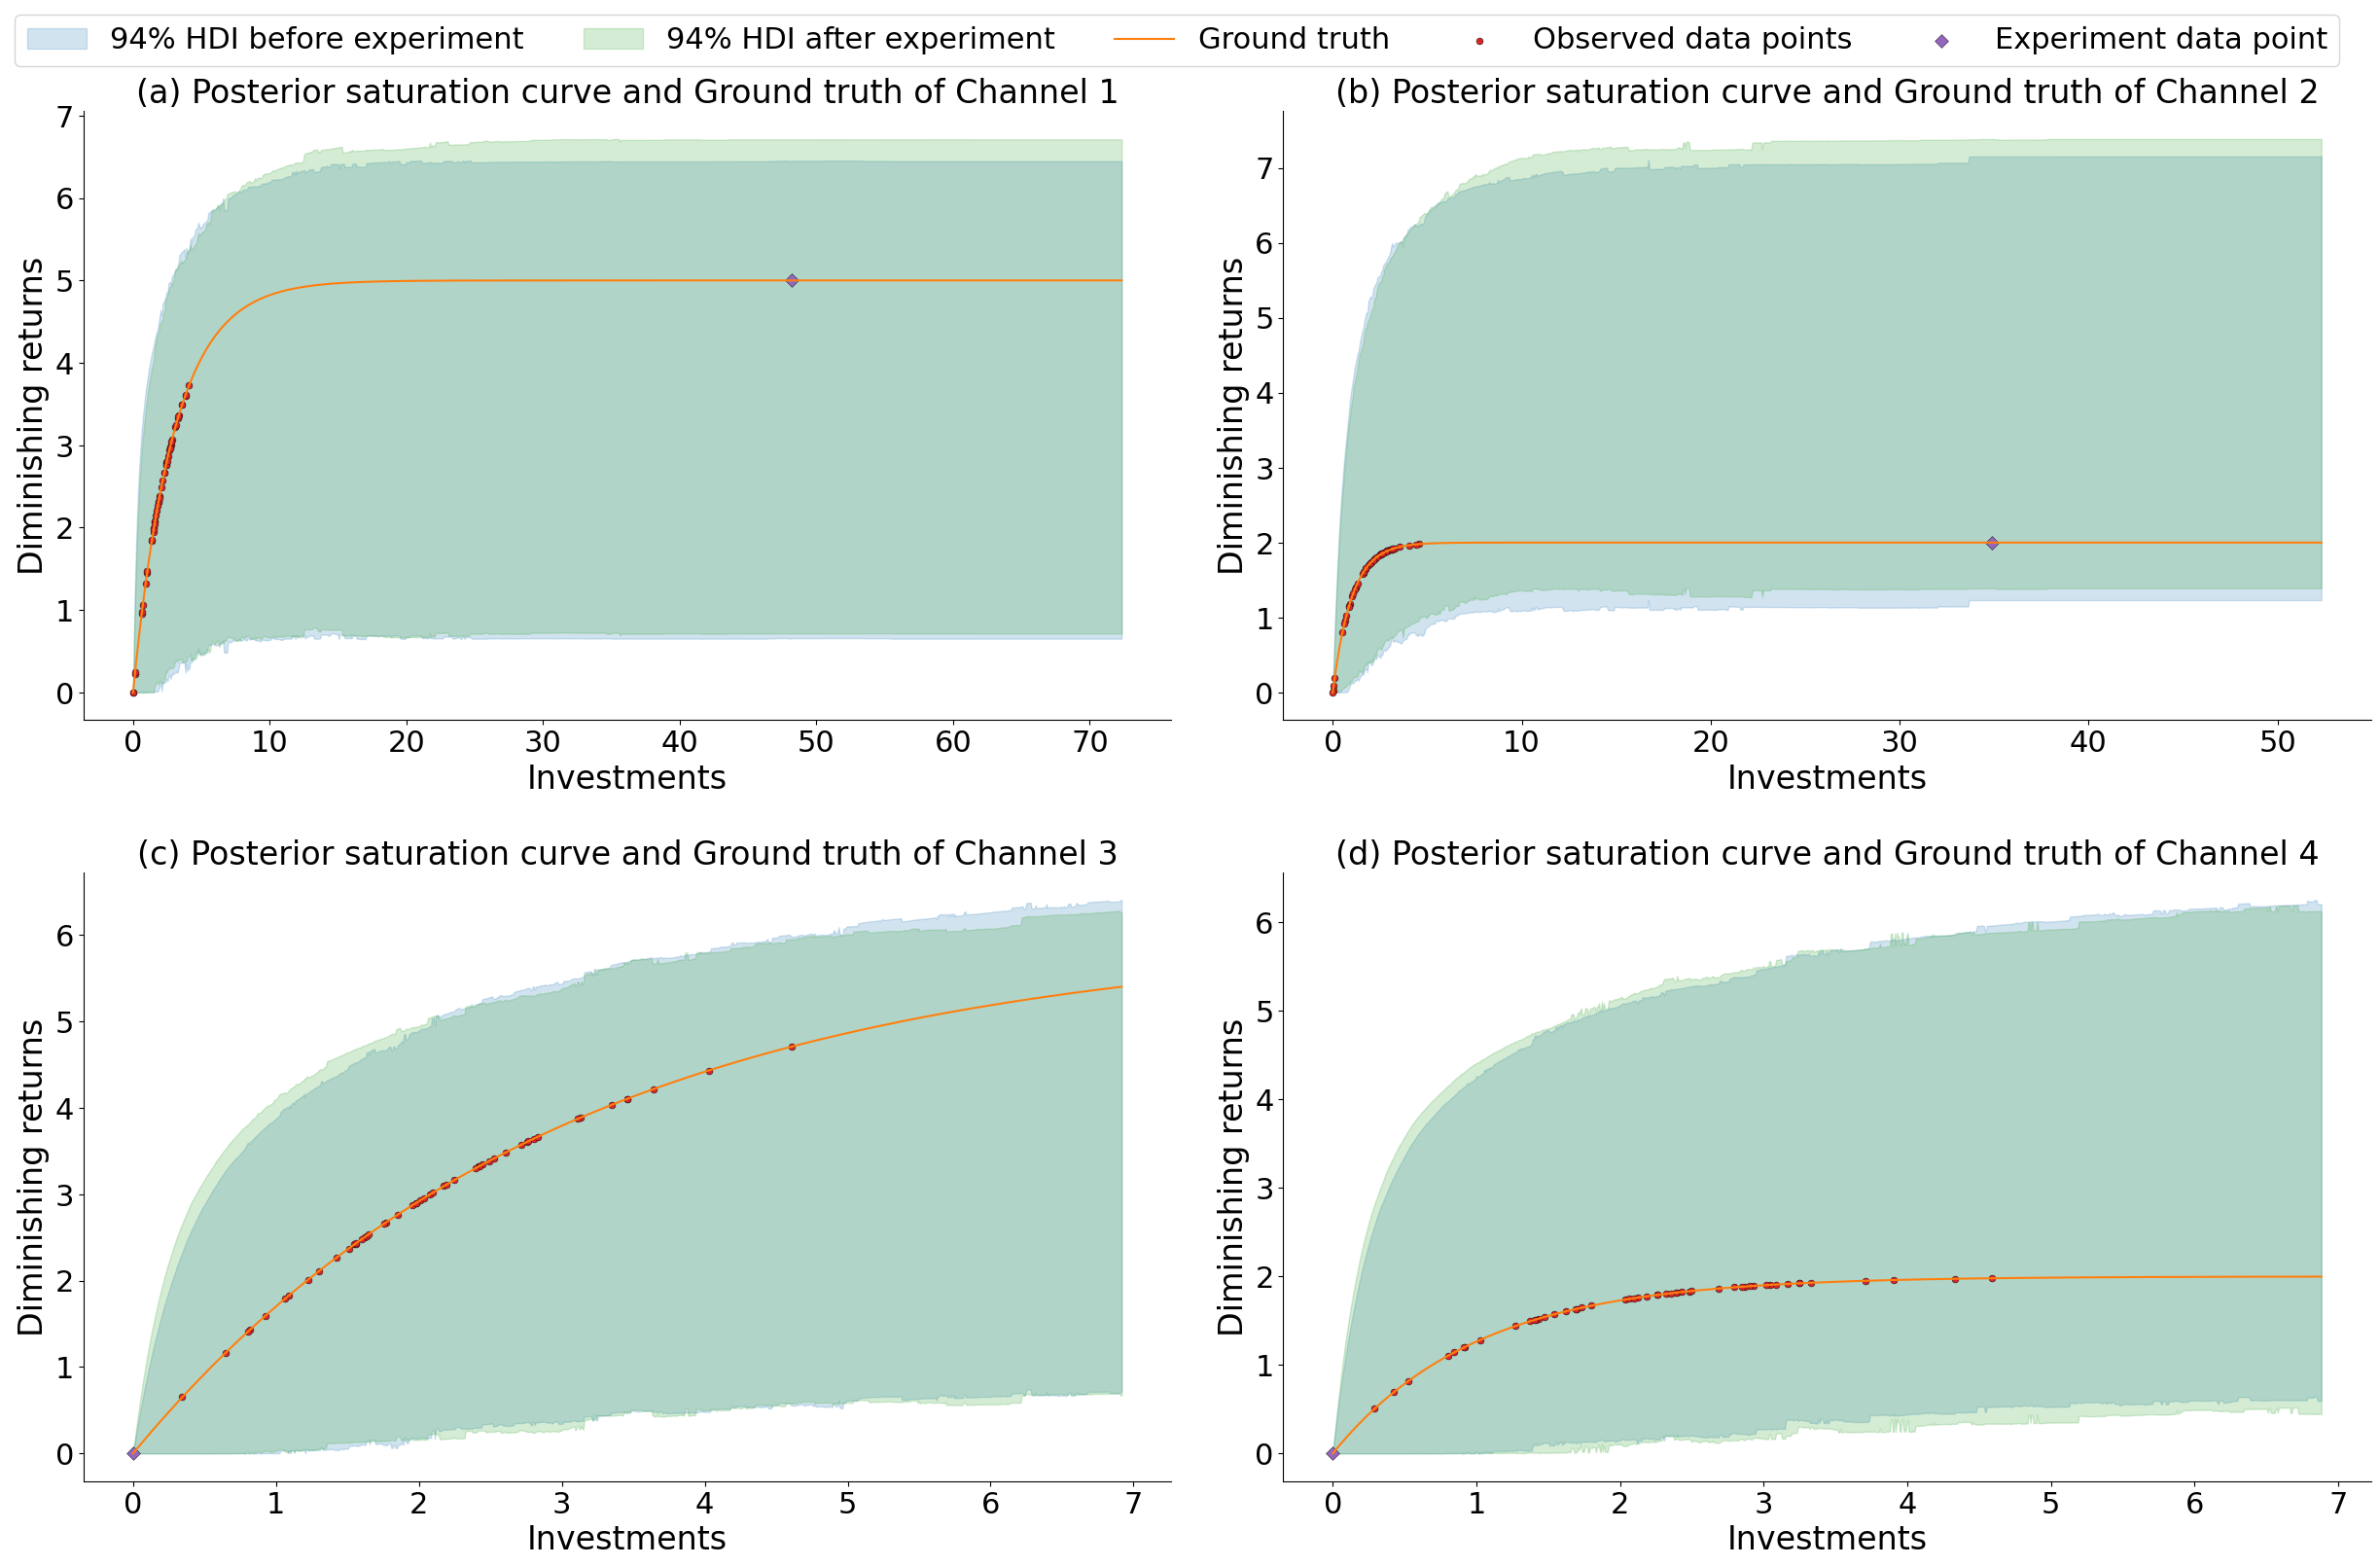

In [13]:
plot_experiment_posterior_vs_ground_truth(
    idata_before_experiment=idata,
    idata_after_experiment=idata_with_dhat_curve_param,
    media_param_df=media_param_df,
    media_feature_names=["media_0", "media_1", "media_2", "media_3"],
    figsize=(20, 28),
    subplot_adjust_kwargs={"top": 0.94, "hspace": 0.35},
)

plot_experiment_posterior_response_curve_multiple(
    idata_before_experiment=idata,
    idata_after_experiment=idata_with_dhat_curve_param,
    data=data,
    experiment_data=d_hat_curve_param,
    media_param_df=media_param_df,
    media_feature_names=["media_0", "media_1", "media_2", "media_3"],
)

### 4.2 Optimize for retention rate parameter

In [14]:
d_hat_retention_rate = (
    ExperimentDesigner(n_media_channels=4, c=future_control_vars)
    .add_posterior_samples(idata)
    .configure_experiment_space(
        lower_bound=np.zeros(4),
        upper_bound=np.ones(4) * 100,
    )
    # .configure_regularization(
    #     x_0=future_media_data,
    #     regularized_type="cost",
    #     regularized_weight=0.1,
    # )
    .configure_target_variables(
        [
            # "saturation",
            # "shape",
            "retention_rate",
        ]
    )
    .find_optimal_experiment()
)
print(
    f"Optimal experiment found for retention rate parameter: "
    f"{d_hat_retention_rate}"
)

generator_with_dhat_retention_rate = (
    generator
    #
    .generate_new_observation(x=d_hat_retention_rate, c=future_control_vars)
)
data_with_dhat_retention_rate = generator_with_dhat_retention_rate.collect()

model_with_dhat_retention_rate = MarketingMixModel(
    model_config=model_config,
    sampler_config=sampler_config,
)

idata_with_dhat_retention_rate = model_with_dhat_retention_rate.fit(
    data_with_dhat_retention_rate.drop(["y"]).to_pandas(),
    data_with_dhat_retention_rate["y"].to_pandas(),
    random_seed=42,
)

  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: -0.09369516323719736
        x: [ 6.852e-19  0.000e+00  0.000e+00  0.000e+00]
      nit: 7
      jac: [ 1.290e-02  1.261e-02  2.176e-02  1.746e-02]
     nfev: 85
     njev: 17
 hess_inv: <4x4 LbfgsInvHessProduct with dtype=float64>
Optimal experiment found for retention rate parameter: [6.85188862e-19 0.00000000e+00 0.00000000e+00 0.00000000e+00]


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [retention_rates, shapes, saturations, gammas, baseline]


Output()

Sampling 4 chains for 3_000 tune and 9_000 draw iterations (12_000 + 36_000 draws total) took 174 seconds.
Sampling: [baseline, gammas, retention_rates, saturations, shapes, y]
Sampling: [y]


Output()

In [15]:
summary_with_dhat_retention_rate_df = az.summary(
    idata_with_dhat_retention_rate
)

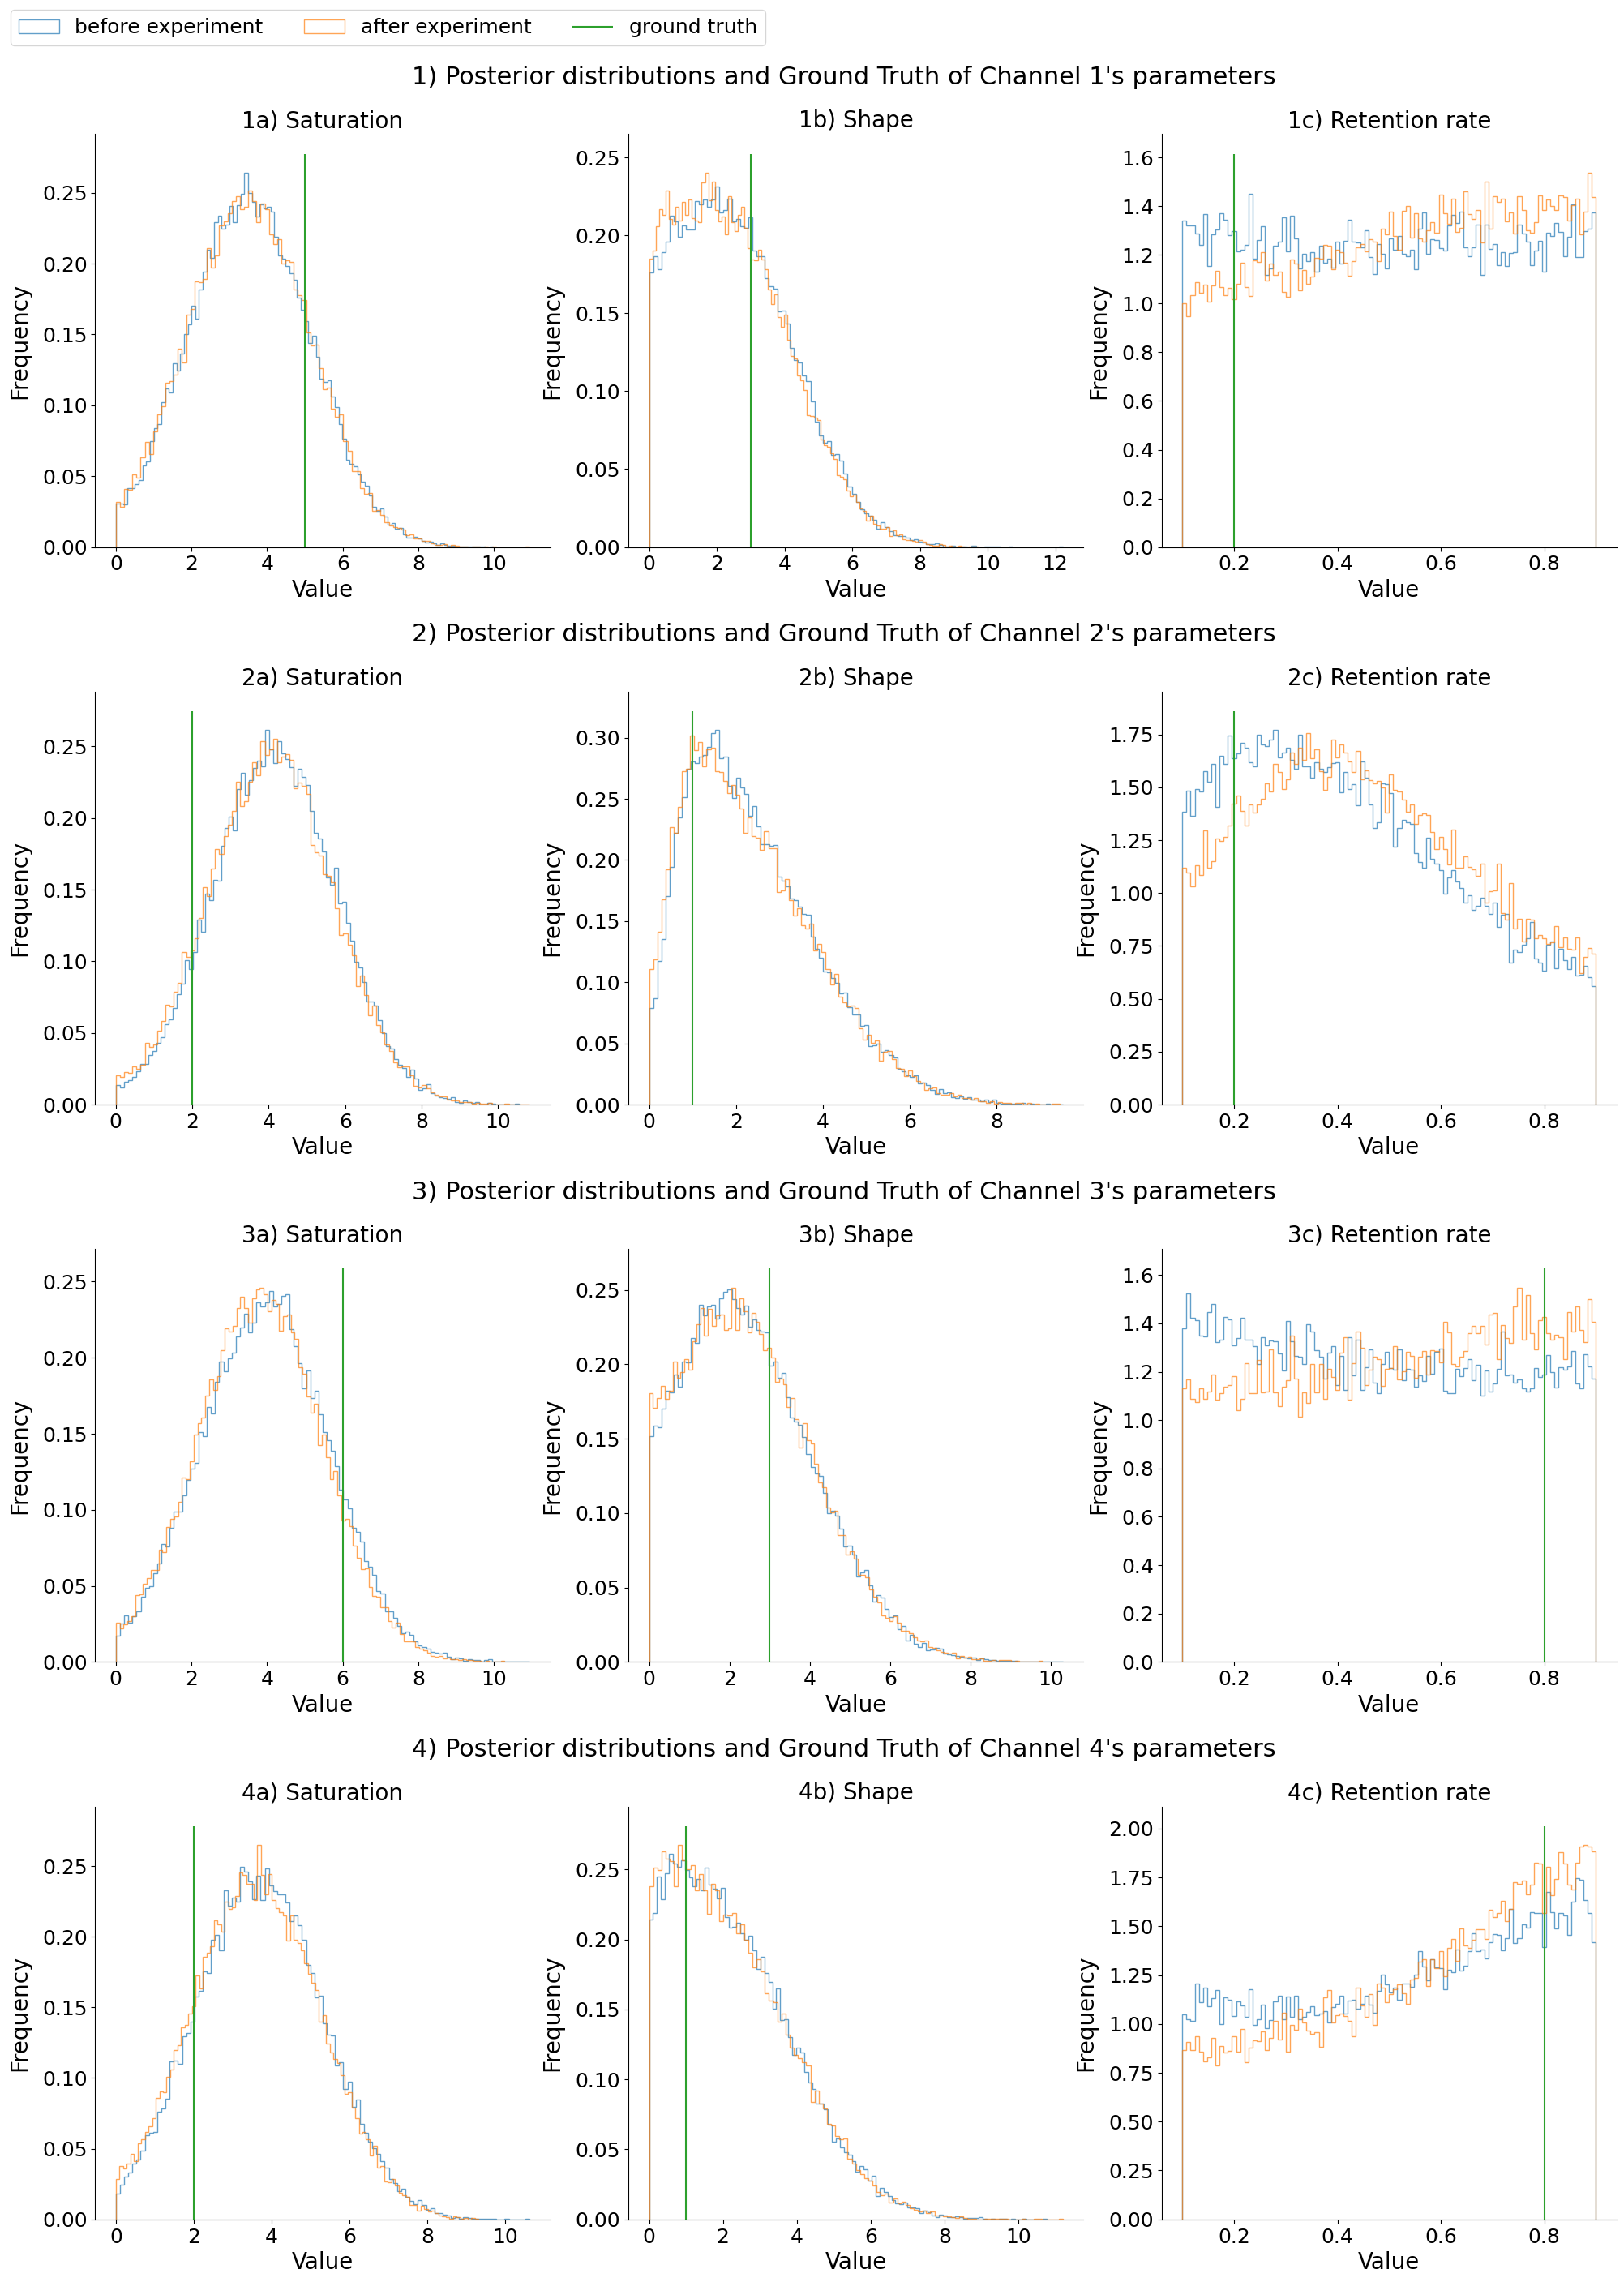

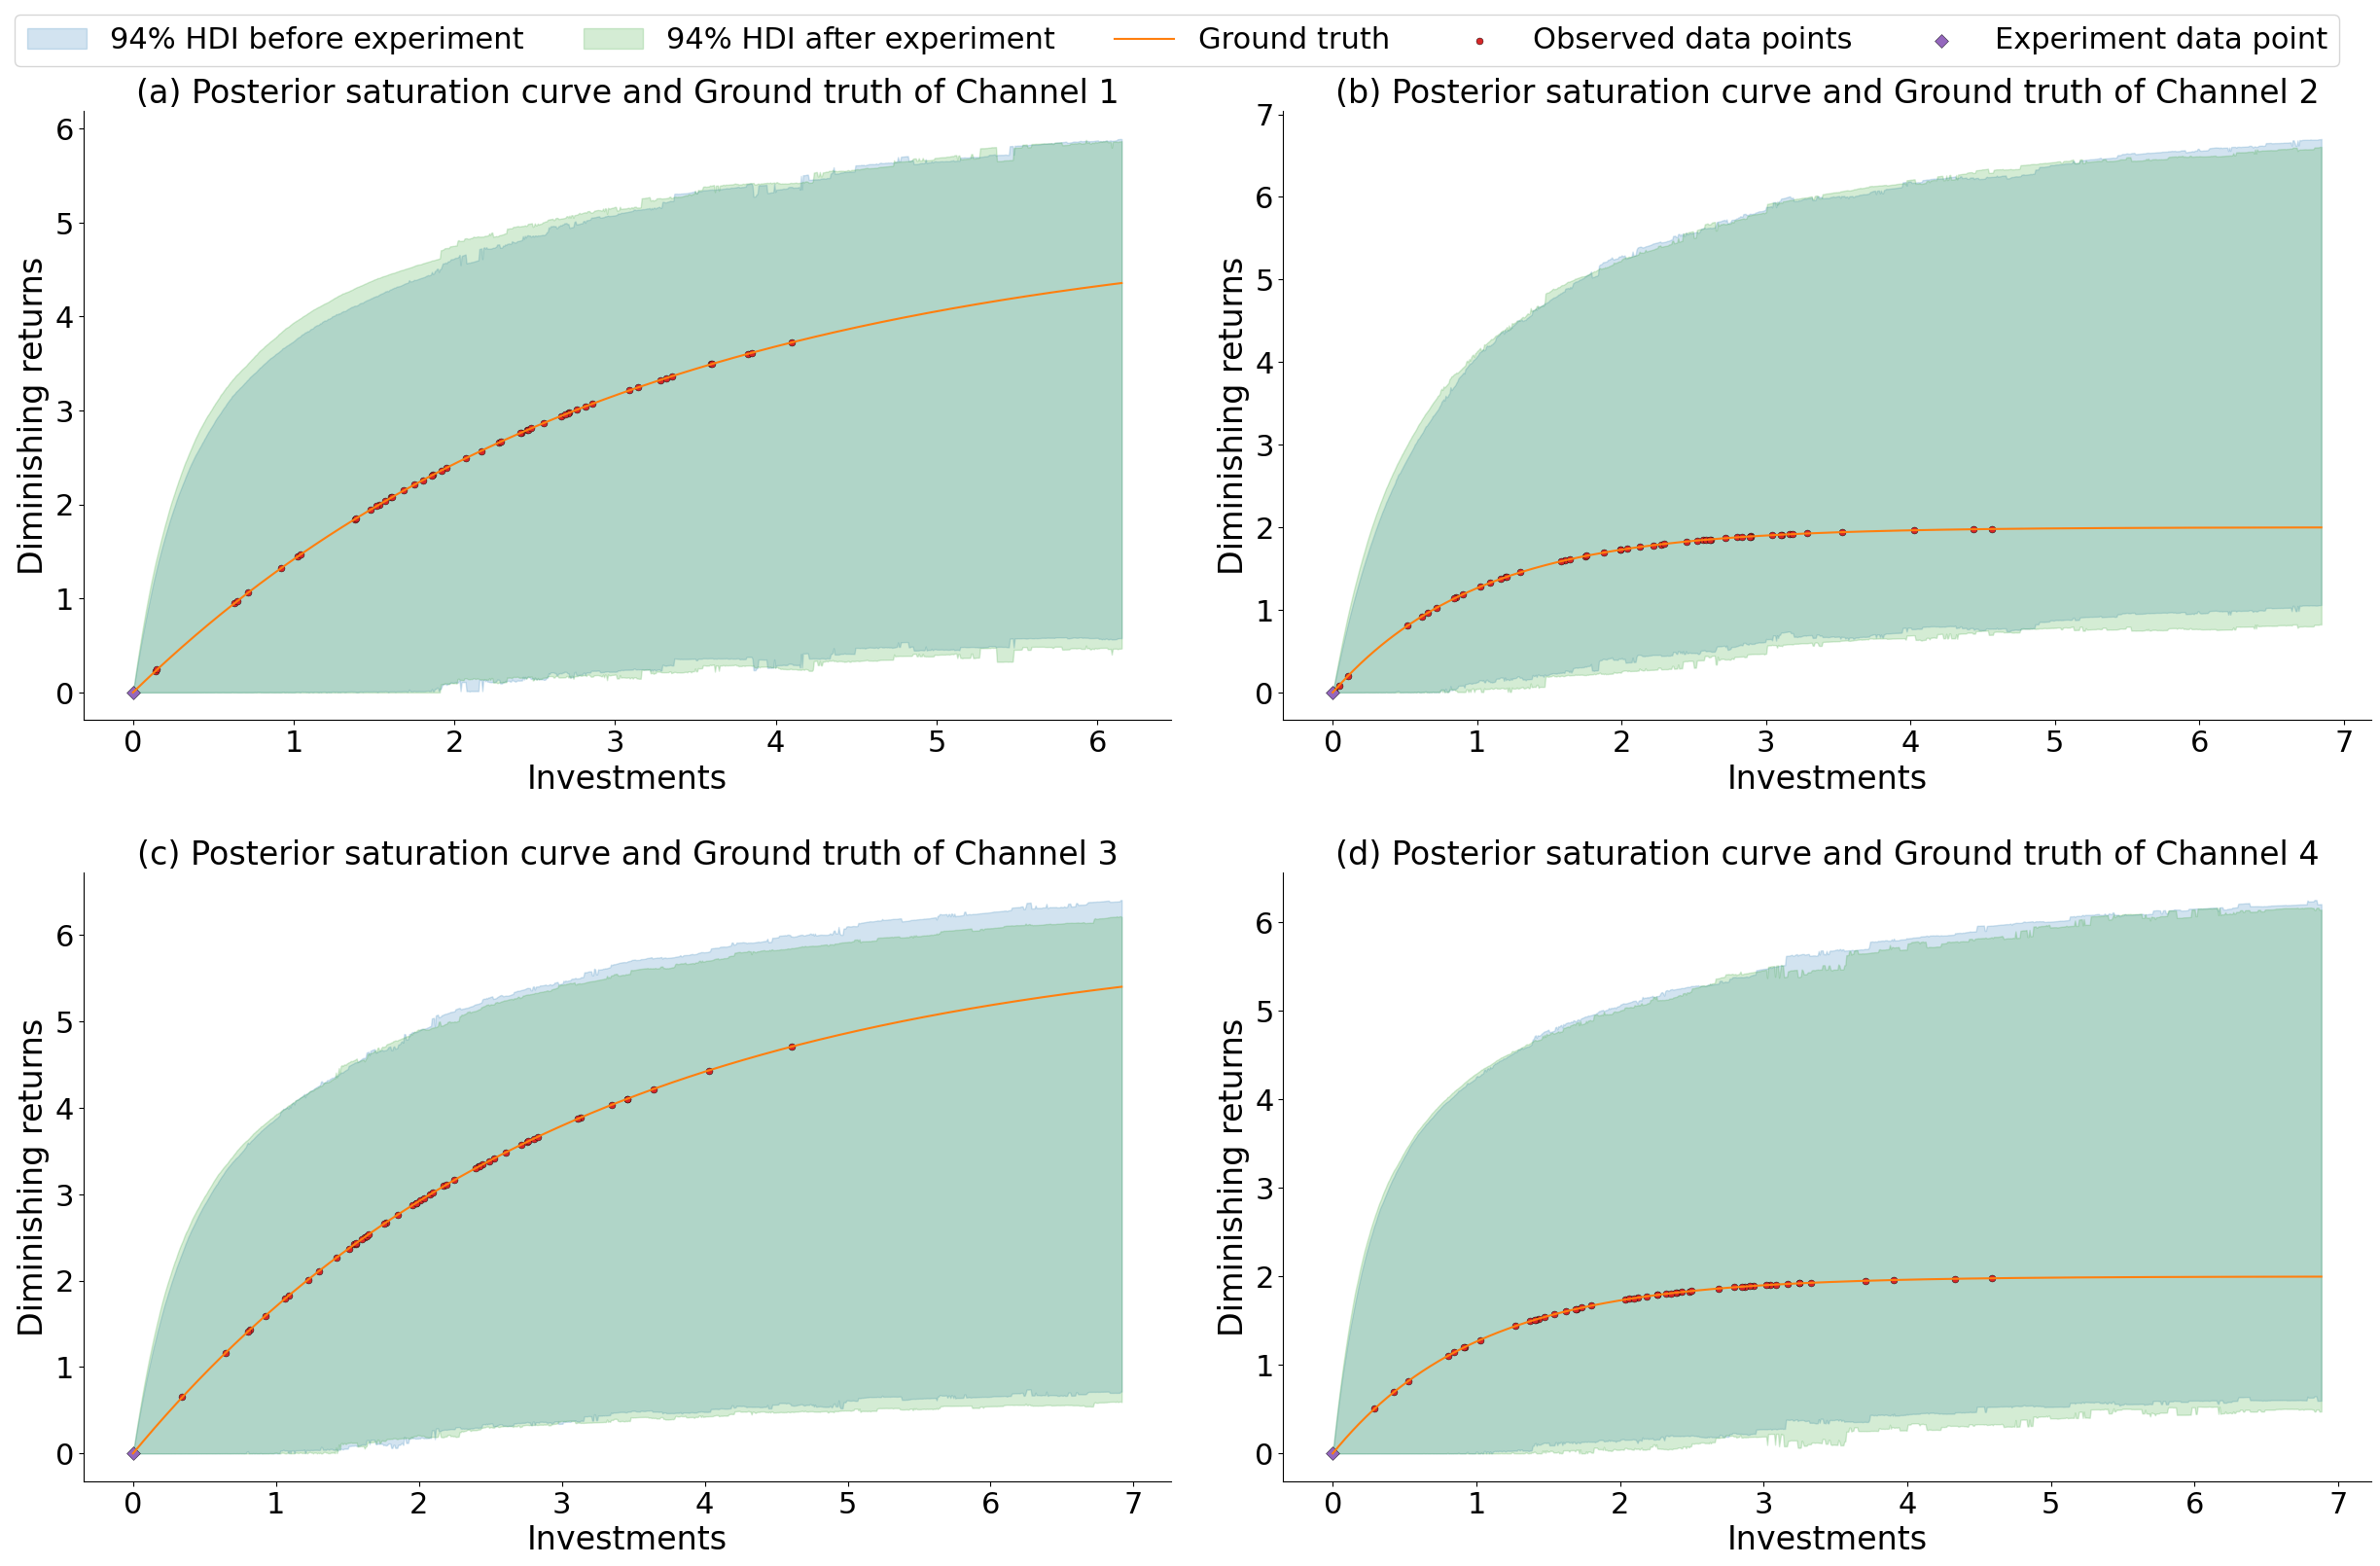

In [16]:
plot_experiment_posterior_vs_ground_truth(
    idata_before_experiment=idata,
    idata_after_experiment=idata_with_dhat_retention_rate,
    media_param_df=media_param_df,
    media_feature_names=["media_0", "media_1", "media_2", "media_3"],
    figsize=(20, 28),
    subplot_adjust_kwargs={"top": 0.94, "hspace": 0.35},
)

plot_experiment_posterior_response_curve_multiple(
    idata_before_experiment=idata,
    idata_after_experiment=idata_with_dhat_retention_rate,
    data=data,
    experiment_data=d_hat_retention_rate,
    media_param_df=media_param_df,
    media_feature_names=["media_0", "media_1", "media_2", "media_3"],
)